In [1]:
# -------------------------------------------
# PHASE 2 - EVT TAIL MODELING
# TASK 1: Setup & Data Import
# -------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto

# Load aligned log returns (from Phase 1)
returns = pd.read_parquet("../data/processed/returns.parquet")

# Preview the structure
returns.head()

,AAPL,BTC-USD,ETH-USD,EURUSD=X,GLD,MSFT,QQQ,SPY,TLT,USDJPY=X,USO,VIXY
Date,,,,,,,,,,,,
2017-11-10,-0.003315,-0.076400,-0.069790,0.004300,-0.008222,-0.002620,-0.000065,-0.000310,-0.015194,-0.004857,-0.003497,0.022040
2017-11-13,-0.004015,0.097510,0.028204,0.001224,0.001485,0.000715,0.001236,0.000929,0.002093,0.002739,-0.003509,0.003109
2017-11-14,-0.015233,0.011559,0.063948,0.000327,0.002059,0.001429,-0.003646,-0.002325,0.006732,-0.000889,-0.022213,0.007903
2017-11-15,-0.013278,0.097529,-0.012740,0.010908,-0.001235,-0.007803,-0.004707,-0.005018,0.010804,-0.001612,-0.003600,0.035964
2017-11-17,-0.005568,-0.020886,0.004432,-0.001308,0.011955,-0.009662,-0.003825,-0.002943,0.007385,-0.003303,0.024979,-0.015956


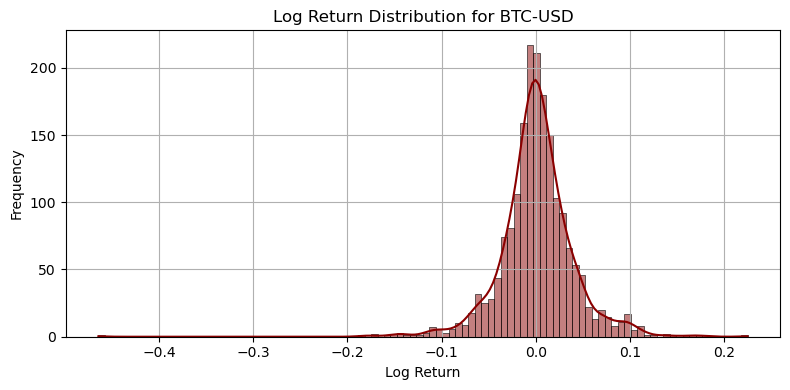

In [3]:
# -------------------------------------------
# Select a target asset for initial EVT analysis
# We start with BTC-USD due to its known fat-tailed behavior
# -------------------------------------------

# Focus asset for EVT modeling
asset = "BTC-USD"
series = returns[asset].dropna()

# Plot full return distribution to visually inspect tails
plt.figure(figsize=(8, 4))
sns.histplot(series, bins=100, kde=True, color="darkred")
plt.title(f"Log Return Distribution for {asset}")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

📉 EVT Threshold (5.0%) = -0.0598
Number of tail events: 94


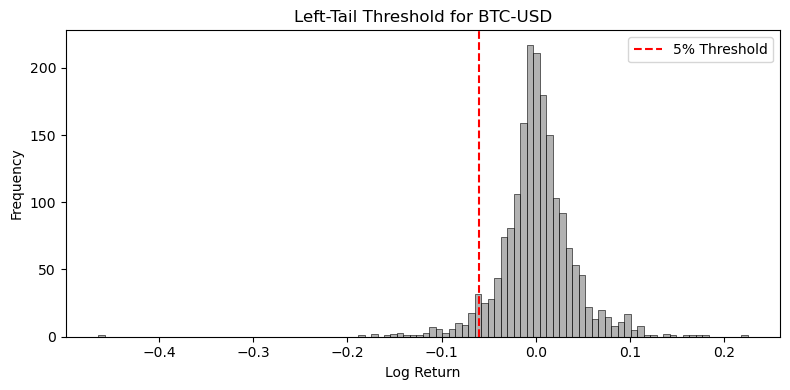

In [5]:
# -------------------------------------------
# PHASE 2 – EVT TAIL MODELING
# TASK 2: Threshold Selection and Tail Extraction
# -------------------------------------------

# Define the tail quantile threshold (e.g., bottom 5% of returns)
quantile_level = 0.05
threshold = series.quantile(quantile_level)

# Extract all values below the threshold (i.e., extreme losses)
extreme_losses = series[series < threshold]

# Print threshold and summary of extracted tail
print(f"📉 EVT Threshold ({quantile_level*100:.1f}%) = {threshold:.4f}")
print(f"Number of tail events: {len(extreme_losses)}")

# Plot: histogram of all returns with threshold marked
plt.figure(figsize=(8, 4))
sns.histplot(series, bins=100, color="grey", alpha=0.6)
plt.axvline(threshold, color="red", linestyle="--", label=f"{int(quantile_level*100)}% Threshold")
plt.title(f"Left-Tail Threshold for {asset}")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# -------------------------------------------
# PHASE 2 – EVT TAIL MODELING
# TASK 3: Fit Generalized Pareto Distribution (GPD)
# -------------------------------------------

# Shift values so that threshold = 0 (as required by GPD)
excess_losses = threshold - extreme_losses  # flip sign for positive excesses

# Fit the Generalized Pareto Distribution to the excess loss sample
# genpareto.fit returns: shape (ξ), location (μ), scale (σ)
shape, loc, scale = genpareto.fit(excess_losses, floc=0)

# Report fitted GPD parameters
print(f"🔧 GPD Fit Results for {asset} (5% Tail)")
print(f"Shape (ξ):  {shape:.4f}")
print(f"Scale (σ):  {scale:.4f}")
print(f"Location (μ):  {loc:.4f} (should be fixed at 0)")

🔧 GPD Fit Results for BTC-USD (5% Tail)
Shape (ξ):  0.2555
Scale (σ):  0.0245
Location (μ):  0.0000 (should be fixed at 0)


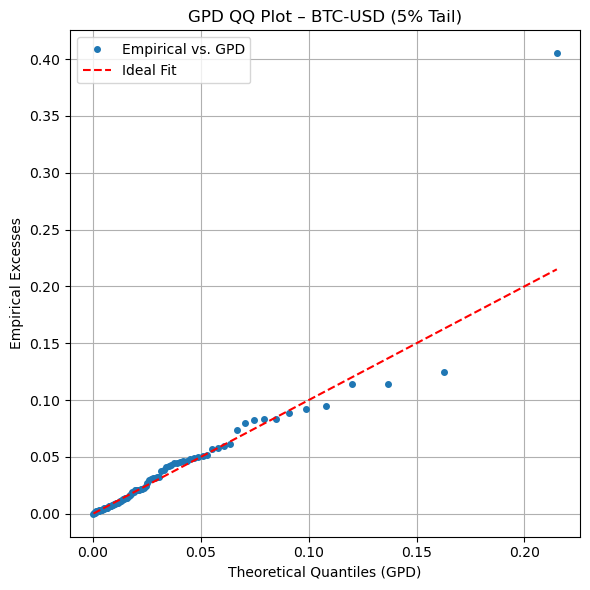

In [9]:
# -------------------------------------------
# PHASE 2 – EVT TAIL MODELING
# TASK 4: Evaluate GPD Fit – QQ and PP Plots
# -------------------------------------------

from scipy.stats import genpareto as gpd

# Sort the excess data
sorted_excess = np.sort(excess_losses)

# Theoretical quantiles (from fitted GPD)
theoretical_q = gpd.ppf(np.linspace(0.01, 0.99, len(sorted_excess)), c=shape, scale=scale, loc=loc)

# QQ Plot: Compare empirical excesses to theoretical GPD quantiles
plt.figure(figsize=(6, 6))
plt.plot(theoretical_q, sorted_excess, 'o', markersize=4, label='Empirical vs. GPD')
plt.plot(theoretical_q, theoretical_q, 'r--', label='Ideal Fit')
plt.title(f"GPD QQ Plot – {asset} ({int(quantile_level*100)}% Tail)")
plt.xlabel("Theoretical Quantiles (GPD)")
plt.ylabel("Empirical Excesses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

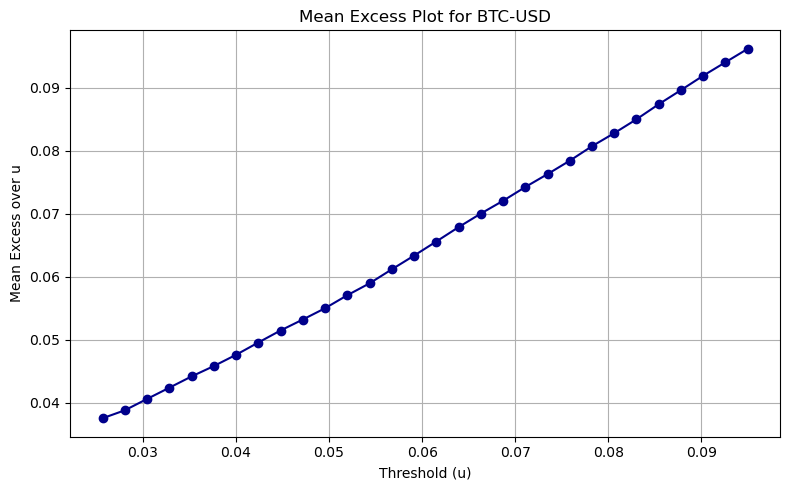

In [11]:
# -------------------------------------------
# PHASE 2 – EVT TAIL MODELING
# TASK 4 CONTINUED: Mean Excess Plot
# -------------------------------------------

# Define thresholds to test above the median (where EVT applies)
test_thresholds = np.linspace(series.quantile(0.80), series.quantile(0.98), 30)

# Calculate mean excess at each threshold
mean_excess = []

for u in test_thresholds:
    excess_data = series[series < u]
    if len(excess_data) > 0:
        excess = u - excess_data
        mean_excess.append(excess.mean())
    else:
        mean_excess.append(np.nan)

# Plot: Mean Excess Function (MEF)
plt.figure(figsize=(8, 5))
plt.plot(test_thresholds, mean_excess, marker='o', color='darkblue')
plt.title(f"Mean Excess Plot for {asset}")
plt.xlabel("Threshold (u)")
plt.ylabel("Mean Excess over u")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# -------------------------------------------
# PHASE 2 – Robust Extension
# TASK 5A: Loop EVT GPD Fitting Across All Assets
# -------------------------------------------

results = []

quantile_level = 0.05  # Use 5% tail for all assets

for asset in returns.columns:
    series = returns[asset].dropna()
    threshold = series.quantile(quantile_level)
    tail_data = series[series < threshold]
    excess = threshold - tail_data  # flip sign

    if len(excess) < 10:
        print(f"⚠️ Not enough tail points for {asset}")
        continue

    shape, loc, scale = genpareto.fit(excess, floc=0)

    results.append({
        "Asset": asset,
        "Threshold": round(threshold, 6),
        "Tail Size": len(excess),
        "Shape (ξ)": round(shape, 4),
        "Scale (σ)": round(scale, 4)
    })

# Convert to DataFrame for export and viewing
gpd_summary_df = pd.DataFrame(results).sort_values("Shape (ξ)", ascending=False)
gpd_summary_df.reset_index(drop=True, inplace=True)

# Preview the results
gpd_summary_df

,Asset,Threshold,Tail Size,Shape (ξ),Scale (σ)
0,USO,-0.037366,94,0.4533,0.0152
1,TLT,-0.016229,94,0.2629,0.0043
2,BTC-USD,-0.059754,94,0.2555,0.0245
3,MSFT,-0.029051,94,0.2134,0.0100
4,EURUSD=X,-0.007231,94,0.2131,0.0022
5,VIXY,-0.061537,94,0.2103,0.0190
6,SPY,-0.018666,94,0.1994,0.0099
7,ETH-USD,-0.075330,94,0.1847,0.0374
8,QQQ,-0.025573,94,0.1489,0.0099
9,GLD,-0.014847,94,0.1433,0.0053


In [15]:
# Save the tail summary for later use (Phase 3: Copulas)
gpd_summary_path = "../data/processed/gpd_summary.csv"
gpd_summary_df.to_csv(gpd_summary_path, index=False)
print(f"✅ Saved tail summary to: {gpd_summary_path}")

✅ Saved tail summary to: ../data/processed/gpd_summary.csv


C:\Users\Public\Documents\iSkysoft\CreatorTemp\ipykernel_17420\1520601159.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gpd_summary_df, x="Asset", y="Shape (ξ)", palette="Reds_r")


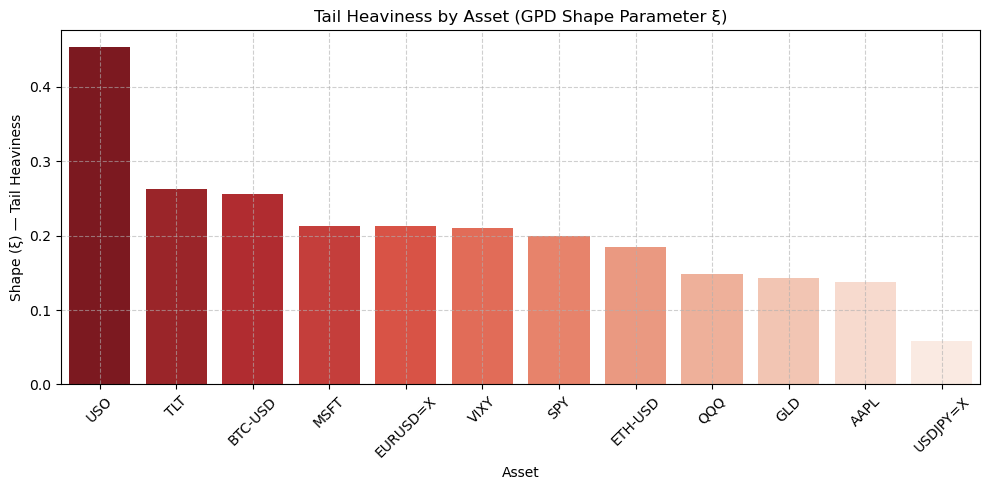

In [17]:
# -------------------------------------------
# Final visualization of tail risk across assets
# -------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(data=gpd_summary_df, x="Asset", y="Shape (ξ)", palette="Reds_r")
plt.title("Tail Heaviness by Asset (GPD Shape Parameter ξ)")
plt.ylabel("Shape (ξ) — Tail Heaviness")
plt.xlabel("Asset")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# -------------------------------------------
# Tail Probability for All Assets (x < -15%)
# -------------------------------------------

target_loss = -0.15  # Extreme return threshold
tail_probs = []

for _, row in gpd_summary_df.iterrows():
    asset = row["Asset"]
    u = row["Threshold"]
    ξ = row["Shape (ξ)"]
    σ = row["Scale (σ)"]
    
    if target_loss >= u:
        tail_probs.append({
            "Asset": asset,
            "P(X < x)": "N/A (x not extreme enough)"
        })
        continue

    excess = u - target_loss
    prob = (1 + (ξ * excess / σ)) ** (-1 / ξ)
    
    tail_probs.append({
        "Asset": asset,
        "P(X < −15%)": f"{prob:.2%}"
    })

# Convert to DataFrame for viewing
tail_prob_df = pd.DataFrame(tail_probs)
tail_prob_df

,Asset,P(X < −15%)
0,USO,3.89%
1,TLT,0.02%
2,BTC-USD,7.46%
3,MSFT,0.25%
4,EURUSD=X,0.00%
5,VIXY,3.89%
6,SPY,0.15%
7,ETH-USD,18.28%
8,QQQ,0.08%
9,GLD,0.00%


In [23]:
# -------------------------------------------
# Tail Fit Sensitivity: 95% vs 99% for All Assets
# -------------------------------------------

quantiles = [0.05, 0.01]  # 5% and 1% left-tail thresholds
sensitivity_results = []

for asset in returns.columns:
    series = returns[asset].dropna()
    
    for q in quantiles:
        threshold = series.quantile(q)
        tail_data = series[series < threshold]
        excess = threshold - tail_data

        if len(excess) < 10:
            sensitivity_results.append({
                "Asset": asset,
                "Quantile": f"{int(q*100)}%",
                "Threshold": round(threshold, 4),
                "Tail Size": len(excess),
                "ξ (Shape)": "N/A",
                "σ (Scale)": "N/A"
            })
            continue

        ξ, loc, σ = genpareto.fit(excess, floc=0)

        sensitivity_results.append({
            "Asset": asset,
            "Quantile": f"{int(q*100)}%",
            "Threshold": round(threshold, 4),
            "Tail Size": len(excess),
            "ξ (Shape)": round(ξ, 4),
            "σ (Scale)": round(σ, 4)
        })

# Convert to DataFrame
gpd_sensitivity_df = pd.DataFrame(sensitivity_results)

# Show sensitivity comparison
gpd_sensitivity_df.head(12)  # First few rows

,Asset,Quantile,Threshold,Tail Size,ξ (Shape),σ (Scale)
0,AAPL,5%,-0.0303,94,0.1380,0.0136
1,AAPL,1%,-0.0522,19,-0.0101,0.0223
2,BTC-USD,5%,-0.0598,94,0.2555,0.0245
3,BTC-USD,1%,-0.1088,19,0.3429,0.0304
4,ETH-USD,5%,-0.0753,94,0.1847,0.0374
5,ETH-USD,1%,-0.1444,19,0.3034,0.0409
6,EURUSD=X,5%,-0.0072,94,0.2131,0.0022
7,EURUSD=X,1%,-0.0123,19,0.3067,0.0022
8,GLD,5%,-0.0148,94,0.1433,0.0053
9,GLD,1%,-0.0243,19,-0.0965,0.0091


In [25]:
# -------------------------------------------
# Save GPD shape parameter sensitivity results
# -------------------------------------------

sensitivity_csv_path = "../data/processed/gpd_sensitivity_summary.csv"
gpd_sensitivity_df.to_csv(sensitivity_csv_path, index=False)
print(f"✅ Saved to: {sensitivity_csv_path}")

✅ Saved to: ../data/processed/gpd_sensitivity_summary.csv


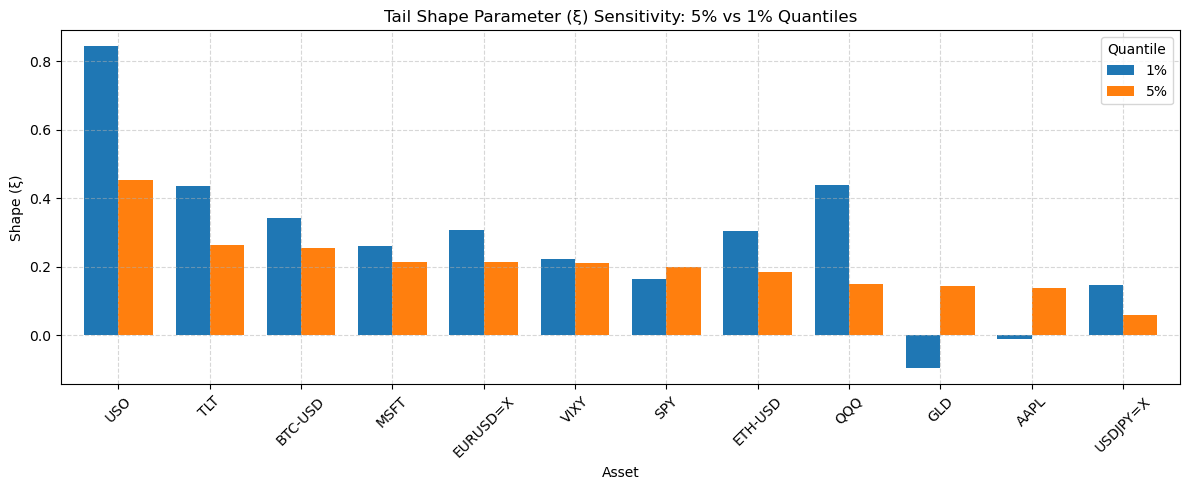

In [27]:
# -------------------------------------------
# Visualize Tail Shape Sensitivity (ξ) at 5% vs 1%
# -------------------------------------------

# Pivot the sensitivity dataframe for plotting
pivot_df = gpd_sensitivity_df.pivot(index="Asset", columns="Quantile", values="ξ (Shape)").dropna()

# Sort assets by ξ at 5% to keep it clean
pivot_df = pivot_df.sort_values("5%", ascending=False)

# Plot side-by-side bars
pivot_df.plot(kind="bar", figsize=(12, 5), width=0.75)
plt.title("Tail Shape Parameter (ξ) Sensitivity: 5% vs 1% Quantiles")
plt.ylabel("Shape (ξ)")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Quantile")
plt.tight_layout()
plt.show()

In [29]:
# -------------------------------------------
# Compare EVT VaR vs Empirical VaR (at 99%)
# -------------------------------------------

alpha = 0.01  # 99% VaR level
var_comparison = []

for _, row in gpd_summary_df.iterrows():
    asset = row["Asset"]
    u = row["Threshold"]
    ξ = row["Shape (ξ)"]
    σ = row["Scale (σ)"]
    
    # Invert the GPD CDF to get x such that P(X > x) = alpha
    var_evt = u - (σ / ξ) * ((alpha) ** (-ξ) - 1)
    
    # Empirical VaR from return distribution
    var_emp = returns[asset].quantile(alpha)
    
    var_comparison.append({
        "Asset": asset,
        "Empirical VaR (1%)": round(var_emp, 4),
        "EVT VaR (1%)": round(var_evt, 4)
    })

var_df = pd.DataFrame(var_comparison)
var_df

,Asset,Empirical VaR (1%),EVT VaR (1%)
0,USO,-0.0738,-0.2743
1,TLT,-0.0243,-0.0548
2,BTC-USD,-0.1088,-0.2749
3,MSFT,-0.0464,-0.1074
4,EURUSD=X,-0.0123,-0.0245
5,VIXY,-0.0939,-0.2092
6,SPY,-0.0354,-0.0934
7,ETH-USD,-0.1444,-0.3469
8,QQQ,-0.0432,-0.0911
9,GLD,-0.0243,-0.0494


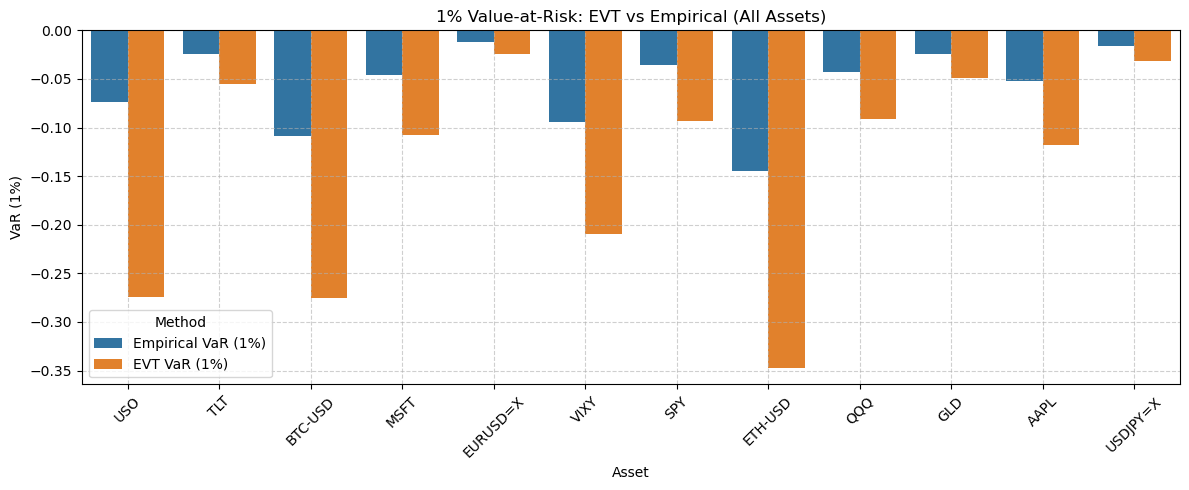

In [31]:
# -------------------------------------------
# Visualize EVT vs Empirical VaR across all assets
# -------------------------------------------

# Melt for side-by-side barplot
var_melt = var_df.melt(id_vars="Asset", 
                       value_vars=["Empirical VaR (1%)", "EVT VaR (1%)"],
                       var_name="Method", value_name="VaR")

plt.figure(figsize=(12, 5))
sns.barplot(data=var_melt, x="Asset", y="VaR", hue="Method")
plt.title("1% Value-at-Risk: EVT vs Empirical (All Assets)")
plt.ylabel("VaR (1%)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [33]:
# -------------------------------------------
# Compute Expected Shortfall (ES) at 1% level using EVT and empirical
# -------------------------------------------

alpha = 0.01  # 99% confidence level
es_comparison = []

for _, row in gpd_summary_df.iterrows():
    asset = row["Asset"]
    u = row["Threshold"]
    ξ = row["Shape (ξ)"]
    σ = row["Scale (σ)"]

    # Skip unstable ES estimates if shape ξ >= 1 (infinite mean)
    if ξ >= 1:
        es_evt = "undefined"
    else:
        # EVT Expected Shortfall formula
        var_evt = u - (σ / ξ) * ((alpha) ** (-ξ) - 1)
        es_evt = var_evt + (σ - ξ * u) / (1 - ξ)

    # Empirical Expected Shortfall: mean of returns below empirical VaR
    empirical_var = returns[asset].quantile(alpha)
    es_empirical = returns[asset][returns[asset] < empirical_var].mean()

    es_comparison.append({
        "Asset": asset,
        "Empirical ES (1%)": round(es_empirical, 4),
        "EVT ES (1%)": round(es_evt, 4) if isinstance(es_evt, float) else es_evt
    })

es_df = pd.DataFrame(es_comparison)
es_df

,Asset,Empirical ES (1%),EVT ES (1%)
0,USO,-0.1236,-0.2155
1,TLT,-0.0335,-0.0431
2,BTC-USD,-0.1558,-0.2215
3,MSFT,-0.0658,-0.0868
4,EURUSD=X,-0.0153,-0.0197
5,VIXY,-0.1305,-0.1687
6,SPY,-0.0542,-0.0764
7,ETH-USD,-0.2039,-0.2839
8,QQQ,-0.0576,-0.0750
9,GLD,-0.0325,-0.0407


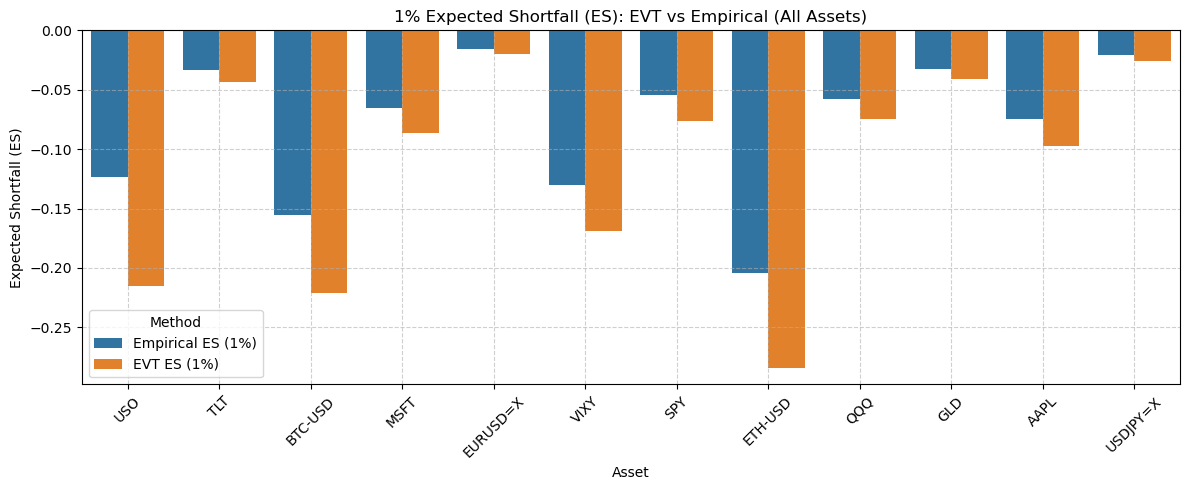

In [35]:
# -------------------------------------------
# Visualize Expected Shortfall: EVT vs Empirical
# -------------------------------------------

# Prepare for barplot
es_melt = es_df.melt(id_vars="Asset", 
                     value_vars=["Empirical ES (1%)", "EVT ES (1%)"],
                     var_name="Method", value_name="ES")

plt.figure(figsize=(12, 5))
sns.barplot(data=es_melt, x="Asset", y="ES", hue="Method")
plt.title("1% Expected Shortfall (ES): EVT vs Empirical (All Assets)")
plt.ylabel("Expected Shortfall (ES)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()